In [6]:
import os 
import pandas as pd 
QWEN_SUMMARY = pd.read_csv("./analysis_stage2_summary.csv")
DF = pd.read_csv("../cleaned_outputs/articles_cleaned_v8.csv")

In [13]:
QWEN_SUMMARY.head(2)

,source_file,S1,S2_exsitu,S2_lab,S2_focus
0,S0001868622001324__META_ABS.xml,NO,NaN,NaN,NaN
1,S0001868623001896__META_ABS.xml,NO,NaN,NaN,NaN


In [14]:
DF.head(1)

,source_file,prism_url,dc_identifier,prism_doi,pii,dc_title,publicationName,aggregationType,pubType,issn,...,openaccessSponsorName,openaccessSponsorType,openaccessUserLicense,scopus_id,scopus_eid,link_self,link_scidir,abstract_length,title_length,authors_length
0,S0001868622001324__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2022.102730,10.1016/j.cis.2022.102730,S0001-8686(22)00132-4,Rising of MXenes: Novel 2D-functionalized nano...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,NaN,NaN,NaN,8.513448e+10,2-s2.0-85134475138,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1497,115,79


In [16]:
pd.merge(DF, QWEN_SUMMARY , on = 'source_file', how = "inner").to_csv("./post_processed_results.csv", index = False)

2025-12-07 19:02:59,503 | INFO | === Analysis started ===
2025-12-07 19:02:59,504 | INFO | CSV path: ./post_processed_results.csv
2025-12-07 19:02:59,505 | INFO | Output dir: ./figs
2025-12-07 19:02:59,506 | INFO | Loading DataFrame...
2025-12-07 19:02:59,707 | INFO | DataFrame loaded: 2681 rows, 39 columns.
2025-12-07 19:02:59,709 | INFO | Saving basic stats...
2025-12-07 19:02:59,781 | INFO |   - df.describe(include='all') → ./figs\describe_all.csv
2025-12-07 19:02:59,782 | INFO |   - S1 value_counts:
S1
YES    1458
NO     1223
Name: count, dtype: int64
2025-12-07 19:02:59,785 | INFO |   - S2_exsitu value_counts:
S2_exsitu
MISSING    1222
NO          914
YES         545
Name: count, dtype: int64
2025-12-07 19:02:59,791 | INFO |   - S2_lab value_counts:
S2_lab
MISSING    1222
YES        1190
NO          269
Name: count, dtype: int64
2025-12-07 19:02:59,798 | INFO |   - S2_focus value_counts:
S2_focus
MISSING                       1222
ZN_EX_SITU_LAYER               517
ZN_IN_SITU_SEI_

In [22]:
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from wordcloud import WordCloud, STOPWORDS

# ------------------------------------------------------------------
# 1) Logging 설정
# ------------------------------------------------------------------
logger = logging.getLogger("postproc_viz")
logger.setLevel(logging.INFO)

# Jupyter에서 중복 핸들러 방지
if logger.handlers:
    logger.handlers.clear()

formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

# 콘솔 출력
ch = logging.StreamHandler()
ch.setLevel(logging.INFO)
ch.setFormatter(formatter)
logger.addHandler(ch)

# 파일 로그
fh = logging.FileHandler("postproc_viz.log", mode="w", encoding="utf-8")
fh.setLevel(logging.INFO)
fh.setFormatter(formatter)
logger.addHandler(fh)

logger.info("Logger initialized.")

# ------------------------------------------------------------------
# 2) DataFrame 로딩 (이미 df가 있으면 재사용)
# ------------------------------------------------------------------
try:
    df
    logger.info("Using existing 'df' in notebook (shape: %s).", (df.shape[0], df.shape[1]))
except NameError:
    df = pd.read_csv("./post_processed_results.csv")
    logger.info("Loaded df from CSV: shape = %s", (df.shape[0], df.shape[1]))

df.head()


c:\Users\PSID_PC_20\anaconda3\envs\acetylene_converter\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-07 19:10:13,677 | INFO | Logger initialized.
2025-12-07 19:10:13,678 | INFO | Using existing 'df' in notebook (shape: (2681, 39)).


,source_file,prism_url,dc_identifier,prism_doi,pii,dc_title,publicationName,aggregationType,pubType,issn,...,scopus_eid,link_self,link_scidir,abstract_length,title_length,authors_length,S1,S2_exsitu,S2_lab,S2_focus
0,S0001868622001324__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2022.102730,10.1016/j.cis.2022.102730,S0001-8686(22)00132-4,Rising of MXenes: Novel 2D-functionalized nano...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85134475138,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1497,115,79,NO,NaN,NaN,NaN
1,S0001868623001896__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2023.103022,10.1016/j.cis.2023.103022,S0001-8686(23)00189-6,Recent progress in 1D MOFs and their applicati...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85175481619,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1021,84,70,NO,NaN,NaN,NaN
2,S000186862300194X__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2023.103027,10.1016/j.cis.2023.103027,S0001-8686(23)00194-X,"Transition metal compounds: From properties, a...",Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85174589910,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,984,83,27,NO,NaN,NaN,NaN
3,S0001868624001726__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2024.103249,10.1016/j.cis.2024.103249,S0001-8686(24)00172-6,The role of graphene aerogels in rechargeable ...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85198714509,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1467,55,75,YES,NO,NO,OTHER
4,S000186862400263X__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2024.103340,10.1016/j.cis.2024.103340,S0001-8686(24)00263-X,Toward self-healing two dimensional MXene coat...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85209347024,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1431,119,92,NO,NaN,NaN,NaN


2025-12-07 19:26:54,483 | INFO | Total rows in df: 2681
2025-12-07 19:26:54,485 | INFO | Label columns for pie charts: ['S1', 'S2_exsitu', 'S2_lab', 'S2_focus']
Pie charts (S1/S2):   0%|          | 0/4 [00:00<?, ?col/s]2025-12-07 19:26:54,499 | INFO | Plotting pie chart for S1: non-null=2681 / total=2681, unique=2


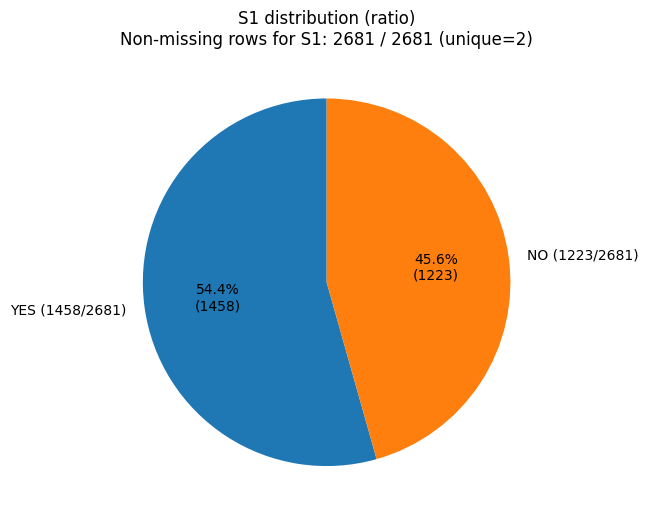

Pie charts (S1/S2):  25%|██▌       | 1/4 [00:00<00:01,  2.07col/s]2025-12-07 19:26:54,990 | INFO | Plotting pie chart for S2_exsitu: non-null=2681 / total=2681, unique=3


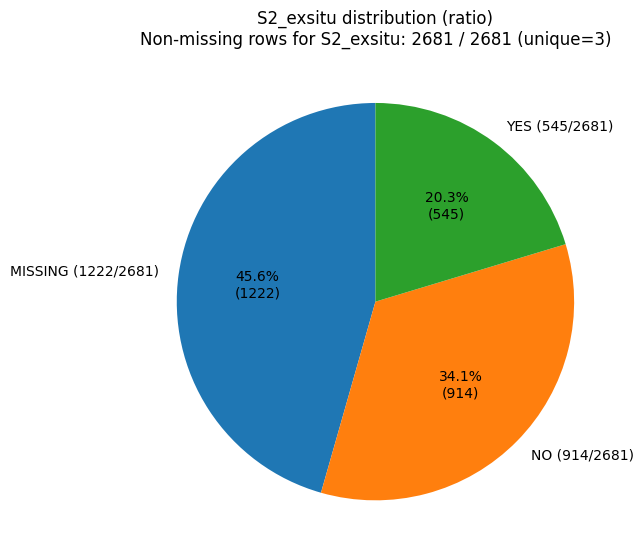

Pie charts (S1/S2):  50%|█████     | 2/4 [00:00<00:00,  2.52col/s]2025-12-07 19:26:55,332 | INFO | Plotting pie chart for S2_lab: non-null=2681 / total=2681, unique=3


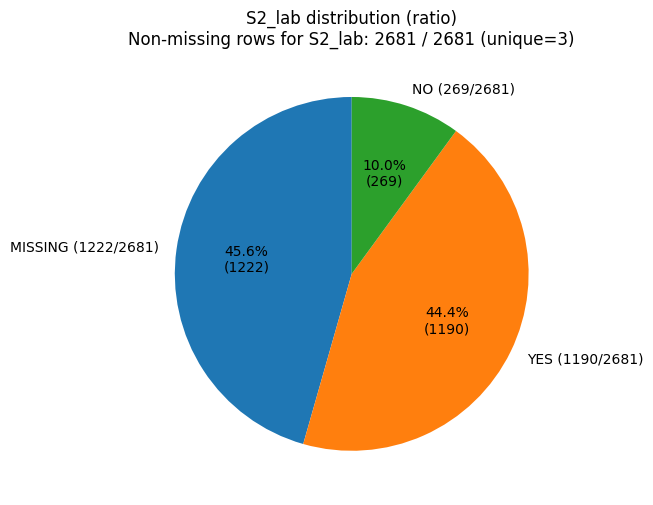

Pie charts (S1/S2):  75%|███████▌  | 3/4 [00:01<00:00,  2.39col/s]2025-12-07 19:26:55,767 | INFO | Plotting pie chart for S2_focus: non-null=2681 / total=2681, unique=6


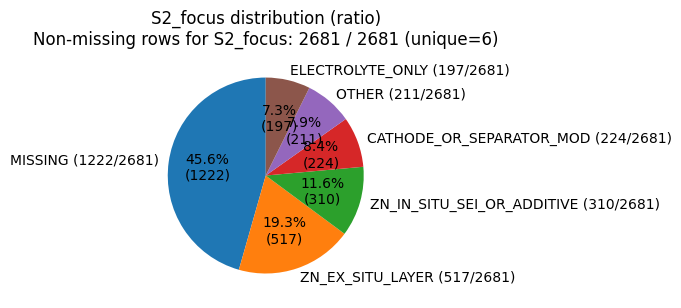

Pie charts (S1/S2): 100%|██████████| 4/4 [00:01<00:00,  2.35col/s]
2025-12-07 19:26:56,201 | INFO | Reason columns detected: []
Reason bar charts: 0col [00:00, ?col/s]


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Jupyter inline 출력
%matplotlib inline

# 전체 행 수 (기준)
total_rows = len(df)
logger.info("Total rows in df: %d", total_rows)

# ------------------------------------------------------------------
# 1) S1, S2_* 비율 파이차트 (상세 개수/비율 표기)
# ------------------------------------------------------------------
label_cols = [c for c in ["S1", "S2_exsitu", "S2_lab", "S2_focus"] if c in df.columns]
logger.info("Label columns for pie charts: %s", label_cols)

def make_autopct(total_count):
    """
    pie chart에서 %와 함께 개수까지 표시해주는 포맷터.
    """
    def autopct(pct):
        count = int(round(pct * total_count / 100.0))
        return f"{pct:.1f}%\n({count})"
    return autopct

for col in tqdm(label_cols, desc="Pie charts (S1/S2)", unit="col"):
    # 결측 제거 후 시리즈
    series = df[col].fillna("MISSING").astype(str)
    non_null = series.size      # 결측 제거 후 데이터 개수
    vc = series.value_counts()
    
    if vc.empty:
        logger.info("Column %s has no data, skipping pie chart.", col)
        continue
    
    logger.info(
        "Plotting pie chart for %s: non-null=%d / total=%d, unique=%d",
        col, non_null, total_rows, vc.size
    )
    
    # 라벨에 "값 (개수/전체비결측)" 형식으로 넣기
    labels = [
        f"{idx} ({cnt}/{non_null})"
        for idx, cnt in zip(vc.index, vc.values)
    ]
    
    plt.figure(figsize=(6.5, 6.5))
    wedges, texts, autotexts = plt.pie(
        vc.values,
        labels=labels,
        autopct=make_autopct(non_null),
        startangle=90
    )
    
    # 메인 타이틀 + 서브 타이틀(몇개 중 몇개)
    main_title = f"{col} distribution (ratio)"
    sub_title = f"Non-missing rows for {col}: {non_null} / {total_rows} (unique={vc.size})"
    plt.title(f"{main_title}\n{sub_title}")
    
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# 2) 이유(reason) 바 차트 (Top N) — 개수/비율/총합 모두 표기
#    - 컬럼명에 'reason'이 들어가는 애들을 자동 탐색
# ------------------------------------------------------------------
reason_cols = [c for c in df.columns if "reason" in c.lower()]
logger.info("Reason columns detected: %s", reason_cols)

TOP_N_REASON = 20

for col in tqdm(reason_cols, desc="Reason bar charts", unit="col"):
    series = df[col].dropna().astype(str)
    non_null = series.size   # 해당 reason 컬럼에서 결측 아닌 행 수
    
    if series.empty:
        logger.info("Column %s is empty, skipping.", col)
        continue
    
    vc_all = series.value_counts()
    vc = vc_all.head(TOP_N_REASON)
    shown_sum = vc.sum()     # 상위 TOP_N_REASON에 포함되는 개수 합
    
    logger.info(
        "Plotting reason bar chart for %s: non-null=%d / total=%d, unique=%d, shown(top)=%d",
        col, non_null, total_rows, vc_all.size, shown_sum
    )
    
    plt.figure(figsize=(30, 30))
    y_pos = np.arange(len(vc))
    plt.barh(y_pos, vc.values)
    plt.yticks(y_pos, vc.index)
    plt.xlabel("Count")
    
    # 메인 타이틀 + 서브 타이틀(몇개 중 몇개)
    main_title = f"Top {len(vc)} reasons in {col}"
    sub_title = (
        f"Shown(top {len(vc)}): {shown_sum} / {non_null} non-null "
        f"({shown_sum/non_null*100:.1f}%)  |  "
        f"Non-null rows: {non_null} / {total_rows}, unique reasons: {vc_all.size}"
    )
    plt.title(f"{main_title}\n{sub_title}")
    
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    
    # 각 바 오른쪽에 "개수 (비율%)" 표시
    for y, count in zip(y_pos, vc.values):
        ratio = count / non_null * 100 if non_null > 0 else 0.0
        plt.text(
            count * 1.01,   # 약간 오른쪽
            y,
            f"{count} ({ratio:.1f}%)",
            va="center"
        )
    
    plt.tight_layout()
    plt.show()


2025-12-07 19:10:29,878 | INFO | Detected ABSTRACT_COL = abstract
2025-12-07 19:10:29,879 | INFO | Detected TITLE_COL    = dc_title
2025-12-07 19:10:29,887 | INFO | Concatenated 2681 rows from column 'abstract' (length=3691578 chars).
2025-12-07 19:10:29,889 | INFO | Concatenated 2681 rows from column 'dc_title' (length=303834 chars).
2025-12-07 19:10:29,898 | INFO | Concatenated abstract+title: 5362 rows (len=3995413 chars).
Wordclouds:   0%|          | 0/3 [00:00<?, ?wc/s]2025-12-07 19:10:29,903 | INFO | Generating wordcloud for 'Abstract only' (chars=3691578).


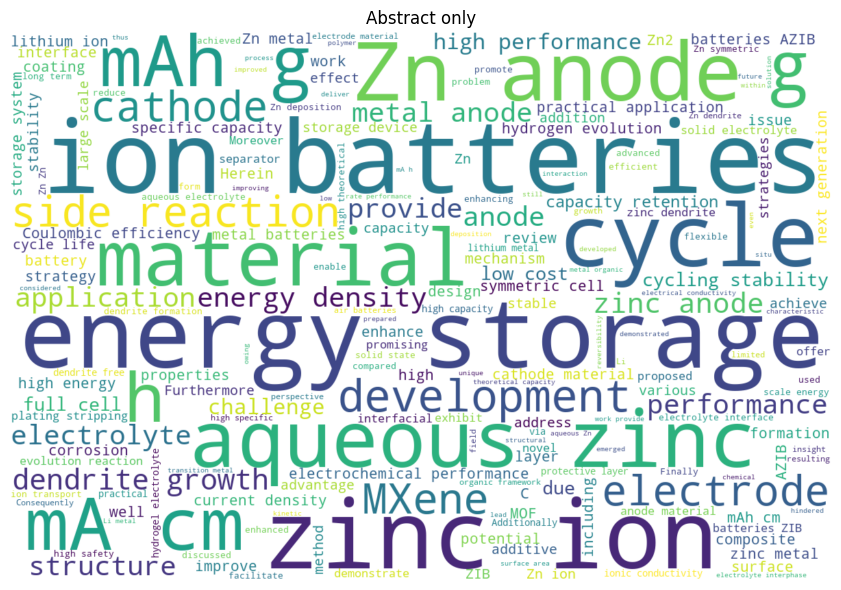

Wordclouds:  33%|███▎      | 1/3 [00:05<00:11,  5.68s/wc]2025-12-07 19:10:35,614 | INFO | Generating wordcloud for 'Title only' (chars=303834).


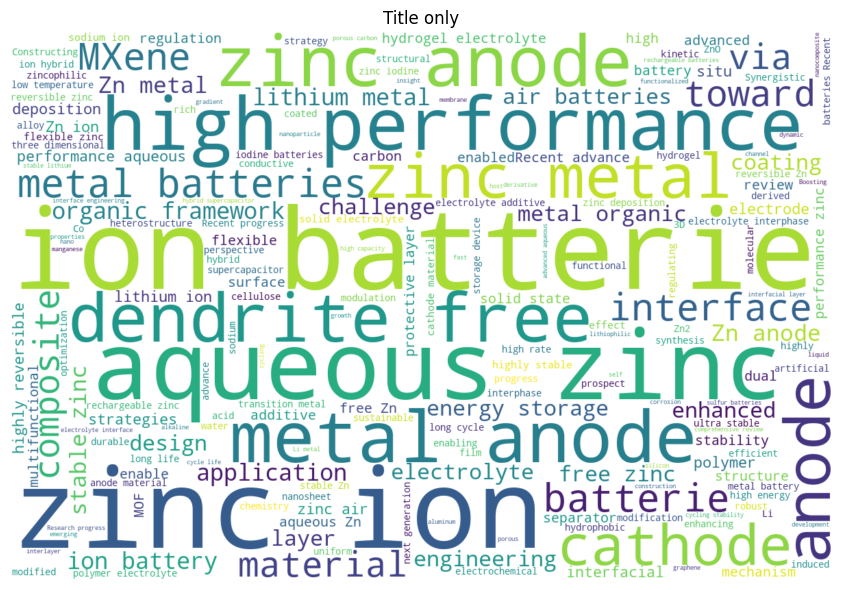

Wordclouds:  67%|██████▋   | 2/3 [00:08<00:04,  4.20s/wc]2025-12-07 19:10:38,752 | INFO | Generating wordcloud for 'Abstract + Title' (chars=3995413).


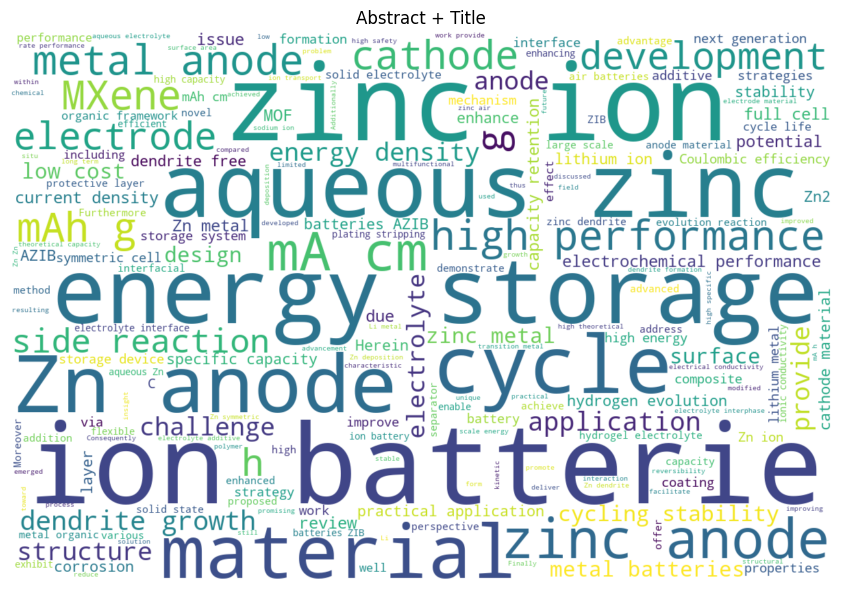

Wordclouds: 100%|██████████| 3/3 [00:14<00:00,  4.76s/wc]


In [24]:
# ------------------------------------------------------------------
# 0) 어떤 컬럼을 abstract / title로 쓸지 자동 탐색 + 수동 override 가능
# ------------------------------------------------------------------
# 후보들 중에서 존재하는 것만 사용
abstract_candidates = ["abstract", "dc_description", "abstract_text", "abstract_cleaned"]
title_candidates    = ["dc_title", "title", "title_cleaned"]

def pick_first_existing(candidates, df):
    for c in candidates:
        if c in df.columns:
            return c
    return None

ABSTRACT_COL = pick_first_existing(abstract_candidates, df)
TITLE_COL    = pick_first_existing(title_candidates, df)

logger.info("Detected ABSTRACT_COL = %s", ABSTRACT_COL)
logger.info("Detected TITLE_COL    = %s", TITLE_COL)

# 필요하면 여기서 강제 지정해도 됨:
# ABSTRACT_COL = "abstract_cleaned"
# TITLE_COL = "dc_title"

if ABSTRACT_COL is None or TITLE_COL is None:
    logger.warning("abstract/title column could not be fully detected. "
                   "Please set ABSTRACT_COL and TITLE_COL manually.")

# ------------------------------------------------------------------
# 1) 텍스트 합치기 함수
# ------------------------------------------------------------------
def concat_text_from_column(df, col_name):
    if col_name is None or col_name not in df.columns:
        logger.warning("Column %s not found. Returning empty text.", col_name)
        return ""
    series = df[col_name].dropna().astype(str)
    text = " ".join(series.tolist())
    logger.info("Concatenated %d rows from column '%s' (length=%d chars).",
                len(series), col_name, len(text))
    return text

# ------------------------------------------------------------------
# 2) 워드클라우드 생성 함수
# ------------------------------------------------------------------
def generate_wordcloud(text, title="WordCloud", max_words=200):
    if not text or text.strip() == "":
        logger.warning("Empty text for wordcloud (%s). Skipping.", title)
        return
    
    # 기본 STOPWORDS + 논문에서 자주 나오는 불용어 조금 추가 (원하면 수정)
    stopwords = set(STOPWORDS)
    extra_stopwords = {
        "using", "use", "results", "result", "based", "also", "however", 
        "may", "one", "two", "new", "study", "studies", "different",
        "can", "show", "shown", "present", "paper"
    }
    stopwords |= extra_stopwords
    
    logger.info("Generating wordcloud for '%s' (chars=%d).", title, len(text))
    
    wc = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        stopwords=stopwords,
        max_words=max_words
    ).generate(text)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 3) abstract / title / abstract+title 워드클라우드 생성
# ------------------------------------------------------------------
texts = {}

# abstract only
texts["Abstract only"] = concat_text_from_column(df, ABSTRACT_COL)

# title only
texts["Title only"] = concat_text_from_column(df, TITLE_COL)

# abstract + title
if ABSTRACT_COL is not None and TITLE_COL is not None:
    ab_series = df[ABSTRACT_COL].dropna().astype(str)
    ti_series = df[TITLE_COL].dropna().astype(str)
    both = ab_series.tolist() + ti_series.tolist()
    texts["Abstract + Title"] = " ".join(both)
    logger.info("Concatenated abstract+title: %d rows (len=%d chars).",
                len(both), len(texts["Abstract + Title"]))
else:
    texts["Abstract + Title"] = ""

# 루프 돌면서 워드클라우드 생성 (tqdm)
for name in tqdm(list(texts.keys()), desc="Wordclouds", unit="wc"):
    generate_wordcloud(texts[name], title=name, max_words=200)


In [25]:
import numpy as np

# -------------------------------------------------------------
# 1) S2_exsitu & S2_lab 둘 다 "YES"로 통과한 논문만 필터링
#    (YES / Y / True / 1 등 유연하게 처리)
# -------------------------------------------------------------
def is_positive_flag(x):
    if pd.isna(x):
        return False
    s = str(x).strip().upper()
    return s in {"YES", "Y", "TRUE", "T", "1"}

if "S2_exsitu" not in df.columns or "S2_lab" not in df.columns:
    logger.warning("S2_exsitu 또는 S2_lab 컬럼이 없습니다. 컬럼명을 확인해 주세요.")
else:
    mask_exsitu = df["S2_exsitu"].apply(is_positive_flag)
    mask_lab    = df["S2_lab"].apply(is_positive_flag)
    mask_both   = mask_exsitu & mask_lab

    df_s2_both = df[mask_both].copy()
    logger.info("S2_exsitu & S2_lab 둘 다 통과한 논문 수: %d / %d",
                df_s2_both.shape[0], df.shape[0])

    display(df_s2_both.head())


2025-12-07 19:13:22,972 | INFO | S2_exsitu & S2_lab 둘 다 통과한 논문 수: 533 / 2681


,source_file,prism_url,dc_identifier,prism_doi,pii,dc_title,publicationName,aggregationType,pubType,issn,...,scopus_eid,link_self,link_scidir,abstract_length,title_length,authors_length,S1,S2_exsitu,S2_lab,S2_focus
18,S000862232400438X__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.carbon.2024.119219,10.1016/j.carbon.2024.119219,S0008-6223(24)00438-X,A “two cooking with one fish” strategy for mod...,Carbon,Journal,fla,00086223,...,2-s2.0-85192685213,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1334,172,77,YES,YES,YES,ZN_EX_SITU_LAYER
20,S0008622324005128__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.carbon.2024.119293,10.1016/j.carbon.2024.119293,S0008-6223(24)00512-8,Chemically tuning graphene via anodic exfoliat...,Carbon,Journal,fla,00086223,...,2-s2.0-85195463640,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1406,140,123,YES,YES,YES,ZN_EX_SITU_LAYER
23,S0008622324006869__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.carbon.2024.119467,10.1016/j.carbon.2024.119467,S0008-6223(24)00686-9,3D porous reduced graphene oxide-coated zinc a...,Carbon,Journal,fla,00086223,...,2-s2.0-85199757705,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1324,132,107,YES,YES,YES,ZN_EX_SITU_LAYER
31,S0009250924006584__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.ces.2024.120358,10.1016/j.ces.2024.120358,S0009-2509(24)00658-4,Waste peanut shell derived porous carbon for d...,Chemical Engineering Science,Journal,fla,00092509,...,2-s2.0-85196508731,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,957,86,49,YES,YES,YES,ZN_EX_SITU_LAYER
32,S0009250924008236__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.ces.2024.120523,10.1016/j.ces.2024.120523,S0009-2509(24)00823-6,Stabilizing Zn anodes via a binder-free MoS2 i...,Chemical Engineering Science,Journal,fla,00092509,...,2-s2.0-85199057004,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,974,110,89,YES,YES,YES,ZN_EX_SITU_LAYER


2025-12-07 19:13:30,805 | INFO | 연도 후보 컬럼들: ['coverDate', 'coverDisplayDate']
2025-12-07 19:13:30,809 | INFO | datetime 파싱 성공한 컬럼 'coverDate' 사용 (예: [2024, 2024, 2024, 2024, 2024] ...)
2025-12-07 19:13:30,811 | INFO | 연도 히스토그램을 그립니다. (min=2019, max=2026)


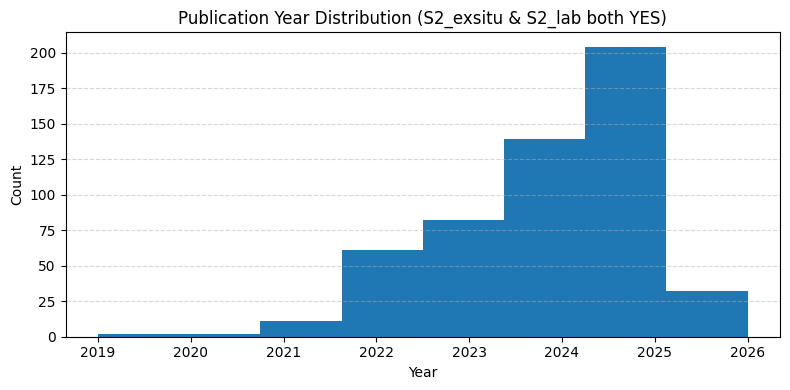

2025-12-07 19:13:31,217 | INFO | S2 통과 서브셋 저널 분포 Top 20:
publicationName
Chemical Engineering Journal                                        115
Energy Storage Materials                                             64
Journal of Colloid and Interface Science                             59
Journal of Power Sources                                             52
Journal of Energy Storage                                            42
Journal of Energy Chemistry                                          23
Journal of Alloys and Compounds                                      23
Electrochimica Acta                                                  19
Nano Energy                                                          18
Applied Surface Science                                              11
Chinese Chemical Letters                                              9
Materials Today Energy                                                8
Colloids and Surfaces A: Physicochemical and Engineering Aspect

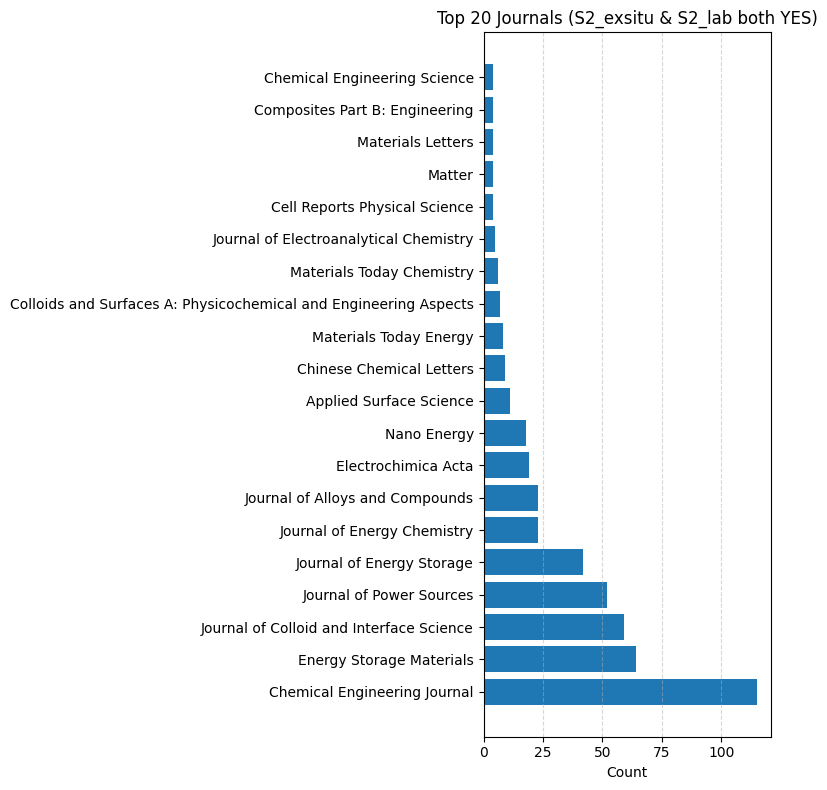

In [26]:
# Jupyter inline
%matplotlib inline

# -------------------------------------------------------------
# 1) 연도(series) 추출 함수
#    - 명시적 후보 → 'year' 포함 컬럼 → 'date' 포함 컬럼 순서로 탐색
# -------------------------------------------------------------
def extract_year_series(df_local):
    """
    df_local에서 연도 정보를 추출해 pd.Series(int)를 반환.
    못 찾으면 None 반환.
    """
    if df_local.empty:
        return None

    # 명시적 후보 우선
    explicit_candidates = [
        "year", "pub_year", "publicationYear", "coverYear",
        "prism_year", "prism:coverDate", "prism_coverDate"
    ]
    # 실제 존재하는 것만
    explicit_candidates = [c for c in explicit_candidates if c in df_local.columns]

    # year/date 자동 탐색
    year_like = [c for c in df_local.columns if "year" in c.lower()]
    date_like = [c for c in df_local.columns if "date" in c.lower()]

    checked_cols = []
    checked_cols.extend(explicit_candidates)
    checked_cols.extend([c for c in year_like if c not in checked_cols])
    checked_cols.extend([c for c in date_like if c not in checked_cols])

    logger.info("연도 후보 컬럼들: %s", checked_cols)

    for col in checked_cols:
        s = df_local[col].dropna()
        if s.empty:
            continue

        # 숫자형 year 시도
        if np.issubdtype(s.dtype, np.number):
            try:
                years = s.astype(int)
                if not years.empty:
                    logger.info("숫자형 year 컬럼 '%s' 사용 (예: %s ...)", col, years.iloc[:5].tolist())
                    return years
            except Exception:
                pass

        # 문자열/객체형 → datetime 파싱 시도
        try:
            dt = pd.to_datetime(s, errors="coerce")
            years = dt.dt.year.dropna().astype(int)
            if not years.empty:
                logger.info("datetime 파싱 성공한 컬럼 '%s' 사용 (예: %s ...)", col, years.iloc[:5].tolist())
                return years
        except Exception:
            continue

    logger.warning("연도 정보를 추출할 수 있는 컬럼을 찾지 못했습니다.")
    return None


# -------------------------------------------------------------
# 2) S2 통과 서브셋 연도 히스토그램
# -------------------------------------------------------------
if "df_s2_both" not in globals() or df_s2_both.empty:
    logger.warning("df_s2_both 가 비어있습니다. 먼저 S2 필터링 셀을 실행해 주세요.")
else:
    years = extract_year_series(df_s2_both)

    if years is not None and not years.empty:
        logger.info("연도 히스토그램을 그립니다. (min=%d, max=%d)", years.min(), years.max())

        bins = min(30, years.nunique())
        plt.figure(figsize=(8, 4))
        plt.hist(years, bins=bins)
        plt.xlabel("Year")
        plt.ylabel("Count")
        plt.title("Publication Year Distribution (S2_exsitu & S2_lab both YES)")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        logger.warning("연도 데이터가 없어 히스토그램을 그릴 수 없습니다.")


# -------------------------------------------------------------
# 3) S2 통과 서브셋 저널 히스토그램 (Top N)
# -------------------------------------------------------------
TOP_N_JOURNAL = 20
JOURNAL_COL = "publicationName"  # 필요하면 다른 이름으로 바꿔도 됨

if "df_s2_both" in globals() and not df_s2_both.empty:
    if JOURNAL_COL in df_s2_both.columns:
        vc = df_s2_both[JOURNAL_COL].fillna("MISSING").value_counts()
        if vc.empty:
            logger.warning("S2 통과 서브셋에서 %s 값이 비어 있습니다.", JOURNAL_COL)
        else:
            top = vc.head(TOP_N_JOURNAL)
            logger.info("S2 통과 서브셋 저널 분포 Top %d:\n%s", len(top), top)

            plt.figure(figsize=(8, max(4, 0.4 * len(top))))
            y_pos = np.arange(len(top))
            plt.barh(y_pos, top.values)
            plt.yticks(y_pos, top.index)
            plt.xlabel("Count")
            plt.title(f"Top {len(top)} Journals (S2_exsitu & S2_lab both YES)")
            plt.grid(axis="x", linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()
    else:
        logger.warning("컬럼 '%s' 이(가) 없습니다. 저널 히스토그램을 건너뜁니다.", JOURNAL_COL)


2025-12-07 19:13:39,561 | INFO | Detected KEYWORD_COL (S2 subset) = None
2025-12-07 19:13:39,563 | INFO | 기존 concat_text_from_column / generate_wordcloud 사용.
2025-12-07 19:13:39,566 | INFO | Concatenated 533 rows from column 'abstract' (length=705422 chars).
2025-12-07 19:13:39,568 | INFO | Concatenated 533 rows from column 'dc_title' (length=61116 chars).
2025-12-07 19:13:39,572 | INFO | S2 subset abstract+title: 1066 rows (len=766539 chars).
2025-12-07 19:13:39,574 | WARNING | 키워드 컬럼을 찾지 못했습니다. keyword 워드클라우드를 건너뜁니다.
S2 subset wordclouds:   0%|          | 0/3 [00:00<?, ?wc/s]2025-12-07 19:13:39,577 | INFO | Generating wordcloud for 'S2 subset - Abstract only' (chars=705422).


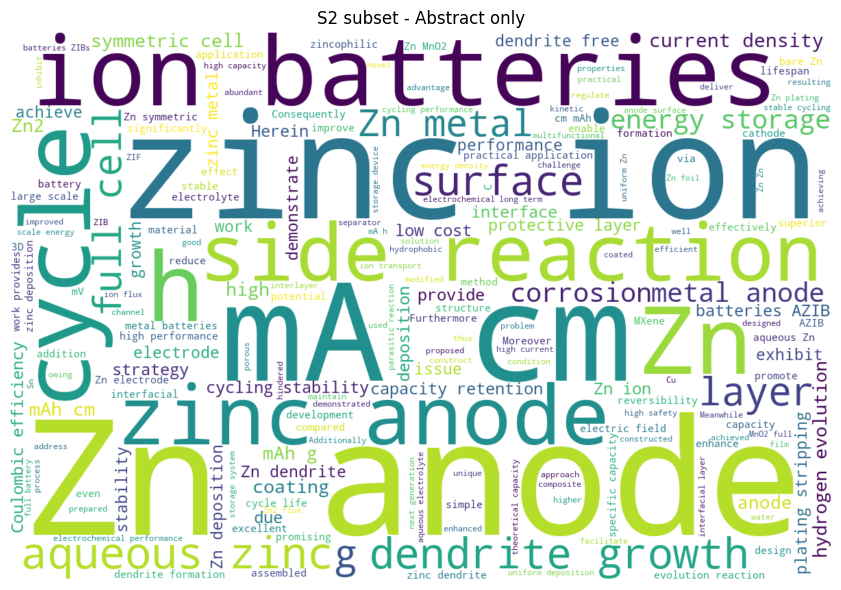

S2 subset wordclouds:  33%|███▎      | 1/3 [00:03<00:06,  3.05s/wc]2025-12-07 19:13:42,629 | INFO | Generating wordcloud for 'S2 subset - Title only' (chars=61116).


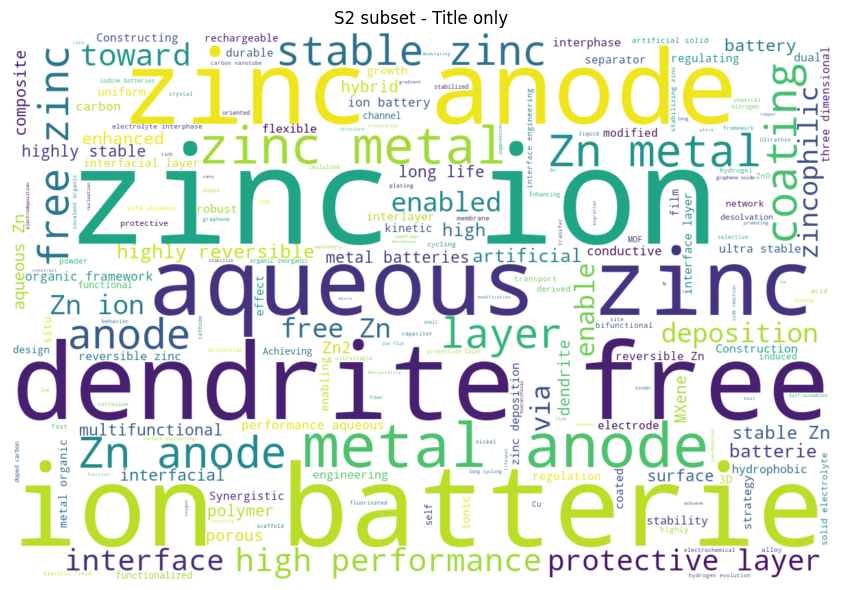

S2 subset wordclouds:  67%|██████▋   | 2/3 [00:05<00:02,  2.80s/wc]2025-12-07 19:13:45,248 | INFO | Generating wordcloud for 'S2 subset - Abstract + Title' (chars=766539).


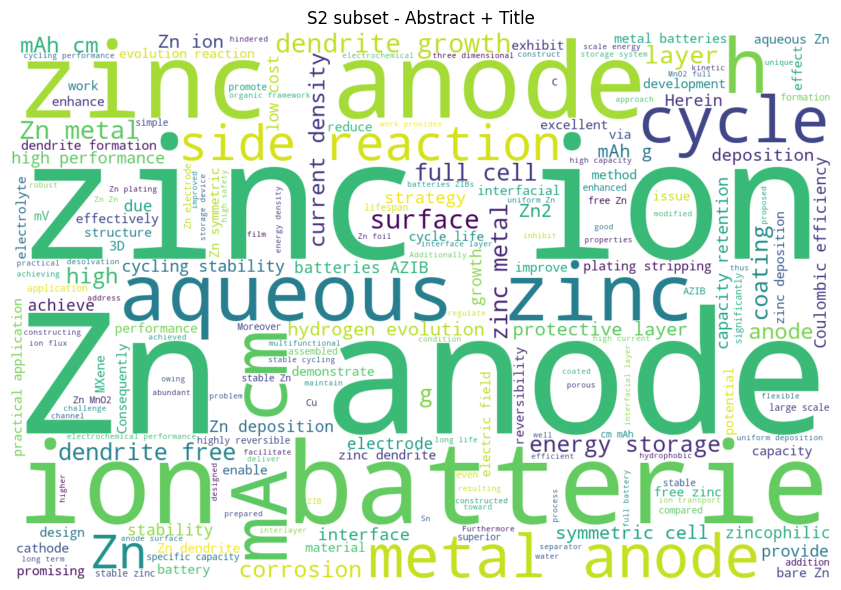

S2 subset wordclouds: 100%|██████████| 3/3 [00:08<00:00,  2.94s/wc]


In [27]:
from tqdm.auto import tqdm

# -------------------------------------------------------------
# 0) keywords 컬럼 후보 자동 탐색
# -------------------------------------------------------------
keyword_candidates = [
    "authkeywords", "authkeywords_cleaned",
    "dc_subject", "keywords", "indexKeywords", "indexkeywords"
]

def pick_first_existing(candidates, df_local):
    for c in candidates:
        if c in df_local.columns:
            return c
    return None

KEYWORD_COL = pick_first_existing(keyword_candidates, df_s2_both) if "df_s2_both" in globals() else None
logger.info("Detected KEYWORD_COL (S2 subset) = %s", KEYWORD_COL)

# -------------------------------------------------------------
# 1) concat_text_from_column / generate_wordcloud 재정의(없을 경우만)
# -------------------------------------------------------------
try:
    concat_text_from_column
    generate_wordcloud
    logger.info("기존 concat_text_from_column / generate_wordcloud 사용.")
except NameError:
    logger.warning("이전 셀에서 워드클라우드 유틸이 정의되지 않아, 간단 버전을 새로 정의합니다.")

    from wordcloud import WordCloud, STOPWORDS

    def concat_text_from_column(df_local, col_name):
        if col_name is None or col_name not in df_local.columns:
            logger.warning("Column %s not found. Returning empty text.", col_name)
            return ""
        series = df_local[col_name].dropna().astype(str)
        text = " ".join(series.tolist())
        logger.info("Concatenated %d rows from column '%s' (length=%d chars).",
                    len(series), col_name, len(text))
        return text

    def generate_wordcloud(text, title="WordCloud", max_words=200):
        if not text or text.strip() == "":
            logger.warning("Empty text for wordcloud (%s). Skipping.", title)
            return
        
        stopwords = set(STOPWORDS)
        extra_stopwords = {
            "using", "use", "results", "result", "based", "also", "however", 
            "may", "one", "two", "new", "study", "studies", "different",
            "can", "show", "shown", "present", "paper"
        }
        stopwords |= extra_stopwords
        
        wc = WordCloud(
            width=1200,
            height=800,
            background_color="white",
            stopwords=stopwords,
            max_words=max_words
        ).generate(text)
        
        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.tight_layout()
        plt.show()


# -------------------------------------------------------------
# 2) S2 통과 서브셋에서 텍스트 모으기
# -------------------------------------------------------------
if "df_s2_both" not in globals() or df_s2_both.empty:
    logger.warning("df_s2_both 가 비어있습니다. 먼저 S2 필터링 셀을 실행해 주세요.")
else:
    texts_s2 = {}

    # (1) abstract only
    if 'ABSTRACT_COL' in globals() and ABSTRACT_COL is not None:
        texts_s2["S2 subset - Abstract only"] = concat_text_from_column(df_s2_both, ABSTRACT_COL)
    else:
        logger.warning("ABSTRACT_COL 이 설정되지 않았습니다. abstract 워드클라우드를 건너뜁니다.")

    # (2) title only
    if 'TITLE_COL' in globals() and TITLE_COL is not None:
        texts_s2["S2 subset - Title only"] = concat_text_from_column(df_s2_both, TITLE_COL)
    else:
        logger.warning("TITLE_COL 이 설정되지 않았습니다. title 워드클라우드를 건너뜁니다.")

    # (3) abstract + title
    if 'ABSTRACT_COL' in globals() and ABSTRACT_COL is not None and \
       'TITLE_COL' in globals() and TITLE_COL is not None:
        ab_series = df_s2_both[ABSTRACT_COL].dropna().astype(str)
        ti_series = df_s2_both[TITLE_COL].dropna().astype(str)
        both = ab_series.tolist() + ti_series.tolist()
        texts_s2["S2 subset - Abstract + Title"] = " ".join(both)
        logger.info("S2 subset abstract+title: %d rows (len=%d chars).",
                    len(both), len(texts_s2["S2 subset - Abstract + Title"]))
    else:
        logger.warning("ABSTRACT_COL / TITLE_COL 중 하나가 없어 abstract+title 워드클라우드를 건너뜁니다.")

    # (4) keywords
    if KEYWORD_COL is not None:
        texts_s2["S2 subset - Keywords"] = concat_text_from_column(df_s2_both, KEYWORD_COL)
    else:
        logger.warning("키워드 컬럼을 찾지 못했습니다. keyword 워드클라우드를 건너뜁니다.")

    # ---------------------------------------------------------
    # 3) 워드클라우드 생성 (tqdm으로 진행률 표시)
    # ---------------------------------------------------------
    for name in tqdm(list(texts_s2.keys()), desc="S2 subset wordclouds", unit="wc"):
        generate_wordcloud(texts_s2[name], title=name, max_words=200)


In [ ]:
df.head(3)
source_file	prism_url	dc_identifier	prism_doi	pii	dc_title	publicationName	aggregationType	pubType	issn	...	scopus_eid	link_self	link_scidir	abstract_length	title_length	authors_length	S1	S2_exsitu	S2_lab	S2_focus
0	S0001868622001324__META_ABS.xml	https://api.elsevier.com/content/article/pii/S...	doi:10.1016/j.cis.2022.102730	10.1016/j.cis.2022.102730	S0001-8686(22)00132-4	Rising of MXenes: Novel 2D-functionalized nano...	Advances in Colloid and Interface Science	Journal	rev	00018686	...	2-s2.0-85134475138	https://api.elsevier.com/content/article/pii/S...	https://www.sciencedirect.com/science/article/...	1497	115	79	NO	NaN	NaN	NaN
1	S0001868623001896__META_ABS.xml	https://api.elsevier.com/content/article/pii/S...	doi:10.1016/j.cis.2023.103022	10.1016/j.cis.2023.103022	S0001-8686(23)00189-6	Recent progress in 1D MOFs and their applicati...	Advances in Colloid and Interface Science	Journal	rev	00018686	...	2-s2.0-85175481619	https://api.elsevier.com/content/article/pii/S...	https://www.sciencedirect.com/science/article/...	1021	84	70	NO	NaN	NaN	NaN
2	S000186862300194X__META_ABS.xml	https://api.elsevier.com/content/article/pii/S...	doi:10.1016/j.cis.2023.103027	10.1016/j.cis.2023.103027	S0001-8686(23)00194-X	Transition metal compounds: From properties, a...	Advances in Colloid and Interface Science	Journal	rev	00018686	...	2-s2.0-85174589910	https://api.elsevier.com/content/article/pii/S...	https://www.sciencedirect.com/science/article/...	984	83	27	NO	NaN	NaN	NaN
3 rows × 39 columns

,source_file,prism_url,dc_identifier,prism_doi,pii,dc_title,publicationName,aggregationType,pubType,issn,...,scopus_eid,link_self,link_scidir,abstract_length,title_length,authors_length,S1,S2_exsitu,S2_lab,S2_focus
0,S0001868622001324__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2022.102730,10.1016/j.cis.2022.102730,S0001-8686(22)00132-4,Rising of MXenes: Novel 2D-functionalized nano...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85134475138,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1497,115,79,NO,NaN,NaN,NaN
1,S0001868623001896__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2023.103022,10.1016/j.cis.2023.103022,S0001-8686(23)00189-6,Recent progress in 1D MOFs and their applicati...,Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85175481619,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,1021,84,70,NO,NaN,NaN,NaN
2,S000186862300194X__META_ABS.xml,https://api.elsevier.com/content/article/pii/S...,doi:10.1016/j.cis.2023.103027,10.1016/j.cis.2023.103027,S0001-8686(23)00194-X,"Transition metal compounds: From properties, a...",Advances in Colloid and Interface Science,Journal,rev,00018686,...,2-s2.0-85174589910,https://api.elsevier.com/content/article/pii/S...,https://www.sciencedirect.com/science/article/...,984,83,27,NO,NaN,NaN,NaN
